<a href="https://colab.research.google.com/github/CONSULTORES427/clases-de-henry/blob/main/Fundamentos_de_Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Instalación e importación de dependencias clave
!pip install torch torchvision matplotlib scikit-learn seaborn

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Configuración de dispositivo agnóstico (GPU si está disponible, sino CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entorno configurado utilizando: {device}")

Entorno configurado utilizando: cuda


Objetivo del Ejercicio: Construir una Red Neuronal Profunda (MLP) para clasificar imágenes del dataset FashionMNIST. El ejercicio exige comparar empíricamente cómo el desacoplamiento del weight decay (AdamW) y las técnicas de regularización (Dropout) mitigan el sobreajuste (overfitting) en comparación con un optimizador tradicional sin regularizar.

In [ ]:
# Transformaciones: Convertir a tensores y normalizar (vital para optimizadores basados en gradiente)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Descarga de conjuntos de entrenamiento y validación
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.8MB/s]


Paso 2: Diseño de la Arquitectura de la Red Neuronal
Aquí aplicamos los fundamentos estructurales: capas densas, funciones de activación no lineales (ReLU) para evitar la pérdida de gradientes, y Dropout para regularización.

In [ ]:
class DeepNeuralNetwork(nn.Module):
    def __init__(self, apply_dropout=False):
        super(DeepNeuralNetwork, self).__init__()
        # Flatten: Transforma la imagen 28x28 a un vector de 784
        self.flatten = nn.Flatten()

        # Arquitectura con capas ocultas
        self.fc1 = nn.Linear(784, 512)
        self.relu1 = nn.ReLU() # Función de activación principal en hidden layers
        self.dropout1 = nn.Dropout(0.3) if apply_dropout else nn.Identity()

        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3) if apply_dropout else nn.Identity()

        self.fc3 = nn.Linear(256, 10) # Capa de salida (10 clases)
        # Nota: No aplicamos Softmax aquí porque CrossEntropyLoss de PyTorch lo incluye internamente.

    def forward(self, x):
        # Fase de Forward Propagation
        x = self.flatten(x)
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        out = self.fc3(x)
        return out

Paso 3: Función de Entrenamiento (Backpropagation en Acción)
Esta función encapsula el ciclo de cálculo de pérdida, retropropagación del error y actualización de pesos.

In [ ]:
def train_model(model, optimizer, criterion, epochs=10):
    model.to(device)
    history = {'train_loss': [], 'test_accuracy': []}

    for epoch in range(epochs):
        model.train() # Modo entrenamiento (activa Dropout)
        running_loss = 0.0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # 1. Resetear gradientes de la iteración anterior
            optimizer.zero_grad()

            # 2. Forward pass: Predecir salida
            outputs = model(inputs)

            # 3. Calcular la función de pérdida (Loss)
            loss = criterion(outputs, labels)

            # 4. Backward pass: Calcular gradientes (Backpropagation)
            loss.backward()

            # 5. Optimización: Actualizar pesos según la regla del optimizador
            optimizer.step()

            running_loss += loss.item()

        # Evaluación al final de la época
        model.eval() # Modo evaluación (desactiva Dropout)
        correct = 0
        total = 0
        with torch.no_grad(): # No necesitamos calcular gradientes para evaluar
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = running_loss/len(trainloader)
        epoch_acc = 100 * correct / total

        history['train_loss'].append(epoch_loss)
        history['test_accuracy'].append(epoch_acc)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.2f}%")

    return history

Paso 4: Ejecución y Comparación Experimental (El Núcleo del Ejercicio)
Aquí se configuran los distintos escenarios para contrastar cómo las estrategias de optimización (SGD tradicional vs. AdamW con Decoupled Weight Decay) y la arquitectura (con/sin Dropout) afectan el aprendizaje.

In [ ]:
# Función de Pérdida común para clasificación multiclase
criterion = nn.CrossEntropyLoss()

print("--- EXPERIMENTO 1: Red Base + Optimizador SGD Básico ---")
model_sgd = DeepNeuralNetwork(apply_dropout=False)
# SGD clásico sin momentum ni regularización
opt_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
history_sgd = train_model(model_sgd, opt_sgd, criterion, epochs=15)

print("\n--- EXPERIMENTO 2: Red Regularizada (Dropout) + Optimizador AdamW ---")
model_adamw = DeepNeuralNetwork(apply_dropout=True)
# AdamW: Adapta la tasa de aprendizaje por parámetro y desacopla la penalización de la norma (L2/Weight Decay)
opt_adamw = optim.AdamW(model_adamw.parameters(), lr=0.001, weight_decay=0.01)
history_adamw = train_model(model_adamw, opt_adamw, criterion, epochs=15)

--- EXPERIMENTO 1: Red Base + Optimizador SGD Básico ---
Epoch 1/15 | Loss: 1.6483 | Val Acc: 70.06%
Epoch 2/15 | Loss: 0.8421 | Val Acc: 75.07%
Epoch 3/15 | Loss: 0.6738 | Val Acc: 76.58%
Epoch 4/15 | Loss: 0.6081 | Val Acc: 77.85%
Epoch 5/15 | Loss: 0.5671 | Val Acc: 78.82%
Epoch 6/15 | Loss: 0.5380 | Val Acc: 80.24%
Epoch 7/15 | Loss: 0.5152 | Val Acc: 80.69%
Epoch 8/15 | Loss: 0.4971 | Val Acc: 81.31%
Epoch 9/15 | Loss: 0.4825 | Val Acc: 81.49%
Epoch 10/15 | Loss: 0.4708 | Val Acc: 82.04%
Epoch 11/15 | Loss: 0.4598 | Val Acc: 82.41%
Epoch 12/15 | Loss: 0.4501 | Val Acc: 82.70%
Epoch 13/15 | Loss: 0.4426 | Val Acc: 82.79%
Epoch 14/15 | Loss: 0.4354 | Val Acc: 83.30%
Epoch 15/15 | Loss: 0.4286 | Val Acc: 83.46%

--- EXPERIMENTO 2: Red Regularizada (Dropout) + Optimizador AdamW ---
Epoch 1/15 | Loss: 0.5844 | Val Acc: 83.75%
Epoch 2/15 | Loss: 0.4136 | Val Acc: 85.55%
Epoch 3/15 | Loss: 0.3760 | Val Acc: 86.01%
Epoch 4/15 | Loss: 0.3545 | Val Acc: 86.91%
Epoch 5/15 | Loss: 0.3355 | Va

Paso 5: Visualización y Análisis (Para el entorno de Colab)
Una visualización gráfica para comparar la velocidad de convergencia y la generalización.

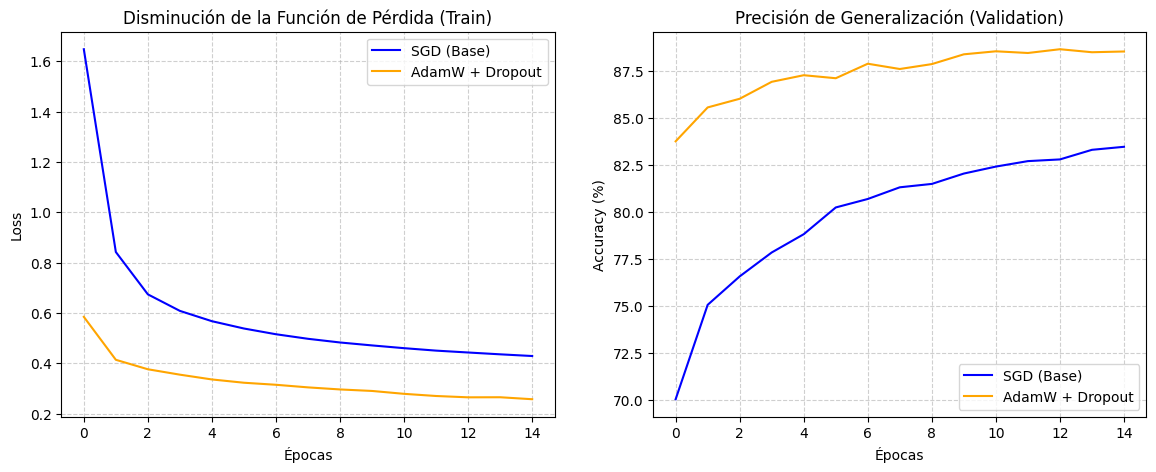

In [ ]:
plt.figure(figsize=(14, 5))

# Gráfico de Función de Pérdida
plt.subplot(1, 2, 1)
plt.plot(history_sgd['train_loss'], label='SGD (Base)', color='blue')
plt.plot(history_adamw['train_loss'], label='AdamW + Dropout', color='orange')
plt.title('Disminución de la Función de Pérdida (Train)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Precisión de Validación
plt.subplot(1, 2, 2)
plt.plot(history_sgd['test_accuracy'], label='SGD (Base)', color='blue')
plt.plot(history_adamw['test_accuracy'], label='AdamW + Dropout', color='orange')
plt.title('Precisión de Generalización (Validation)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()